[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/Quantlets/Ch_11/ATS_ch11_seminar/ATS_ch11_seminar.ipynb)

# Advanced Time Series Analysis and Forecasting — Seminar 11: Spectral and wavelet analysis

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 11; the slides give the definitions ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.

> Quantlet `ATS_ch11_seminar`: student version of the Seminar 11 notebook. Solved exercises (A1, A3, A5, A7, B1, B3, B5, B7) are shown with code and output; the proposed exercises (A2, A4, A6, A8, B2, B4, B6, B8, C1, C2) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_11'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
# PyWavelets gives the wavelet filters (Colab: installed here if missing)
%pip install -q PyWavelets

In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- The numpy engine of Chapter 11, the data helpers and the functions of the solved tasks.

In [ ]:
import time
from scipy import signal, sparse, linalg
from scipy.sparse.linalg import spsolve
from scipy.ndimage import convolve1d
SEED = 2026
END = '2026-09-18'
PW_AR4 = (2.7607, -3.8106, 2.6535, -0.9238)
AR2 = (1.3, -0.7)
AR2_SHARP = (1.6, -0.9)
BC_Q = (6, 32)
BC_M = (18, 96)
CEE = ['RO', 'PL', 'HU', 'CZ']
GEO_LAB = {'RO': 'Romania', 'PL': 'Poland', 'HU': 'Hungary', 'CZ': 'Czechia', 'EA20': 'euro area', 'EA': 'euro area'}
GEO_COL = {'RO': st.IDAred, 'PL': st.Purple, 'HU': st.Forest, 'CZ': st.Orange, 'EA20': st.MainBlue, 'EA': st.MainBlue}
_MEM = {}
W0 = 6.0
FOURIER_FACTOR = 4 * np.pi / (W0 + np.sqrt(2 + W0 ** 2))
KERNEL_CONST = {'bartlett': (1.0, 1.0, 0.6666666666666666), 'parzen': (2.0, 6.0, 0.539285), 'qs': (2.0, 1.421223, 1.0), 'tukey': (2.0, 2.4674011002723395, 0.75)}
_DPSS = {}
A2 = {'lams': {'quarterly': 1600, 'monthly': 129600, 'annual': 6.25}, 'h': 8}
A3 = {'n': 200, 'M': 20, 'f': 2.0}
A4 = {'n': 256, 'NW': 3, 'f': 0.8, 'peaks': (0.1, 0.115)}
A5 = {'beta': 0.8, 'd': 2, 'sx2': 1.0, 'su2': 0.5, 'K': 7}
A6 = {'a11': 0.5, 'a12': 0.4, 'a22': 0.6}
A7 = {'x': [2.0, 4.0, 3.0, 7.0, 6.0, 5.0, 9.0, 8.0]}
A8 = {'n': 520, 'period': 52}


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def online(fn, *a, tries=4, **k):
    """Online sources (Eurostat, FRED) with a few retries."""
    key = (fn.__name__,) + a + tuple(sorted(k.items()))
    if key in _MEM:
        return _MEM[key]
    for i in range(tries):
        try:
            _MEM[key] = fn(*a, **k)
            return _MEM[key]
        except Exception:
            if i == tries - 1:
                raise
            time.sleep(5 * (i + 1))


def gdp(geo, end='2026-06-30'):
    """100 x log real GDP (chain-linked volumes 2010, seasonally and calendar adjusted), Eurostat namq_10_gdp."""
    s = online(read_eurostat, 'namq_10_gdp', f'Q.CLV10_MEUR.SCA.B1GQ.{geo}')
    return (100 * np.log(s.loc['1995-01-01':end])).rename(geo)


def ip(geo, adj='SCA'):
    """100 x log industrial production (B-D: mining, manufacturing, energy), 2021 = 100, Eurostat sts_inpr_m."""
    s = online(read_eurostat, 'sts_inpr_m', f'M.PRD.B-D.{adj}.I21.{geo}')
    return (100 * np.log(s.loc['2000-01-01':])).rename(geo)


def hicp(geo, start='2001-01-01'):
    """HICP annual rate of change (%), all items, Eurostat prc_hicp_minr."""
    s = online(read_eurostat, 'prc_hicp_minr', f'M.RCH_A.TOTAL.{geo}')
    return s.loc[start:].rename(geo)


def weekly_returns(name, start='2000-01-01', end=END):
    """Weekly log returns in % from Friday closes (the last close of each week)."""
    p = load_close(name, start=start, end=end).resample('W-FRI').last().dropna()
    return (100 * np.log(p).diff().dropna()).rename(name)


def brent_weekly(start='2000-01-01', end=END):
    p = online(read_fred, 'DCOILBRENTEU').loc[start:end].dropna()
    p = p[p > 0].resample('W-FRI').last().dropna()
    return (100 * np.log(p).diff().dropna()).rename('brent')


def daily_common(names, start='2000-01-01', end=END):
    """Daily log returns in % on the days on which all markets traded (prices aligned first)."""
    p = pd.concat([load_close(n, start=start, end=end) for n in names], axis=1, join='inner').dropna()
    return 100 * np.log(p).diff().dropna()


def per_axis(ax, lo, hi, ticks, label='period'):
    """Logarithmic period axis (long cycles on the left)."""
    ax.set_xscale('log')
    ax.set_xlim(hi, lo)
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks])
    ax.minorticks_off()
    ax.set_xlabel(label)


def shade_band(ax, lo, hi, label='business-cycle band'):
    ax.axvspan(lo, hi, color=st.Amber, alpha=0.15, lw=0, label=label)


def ip_growth(geo, adj='SCA'):
    return ip(geo, adj).diff().dropna()


def gdp_growth(geo, end='2026-06-30'):
    return gdp(geo, end).diff().dropna()


def bet_daily():
    return (100 * np.log(load_close('bet', start='2000-01-01', end=END)).diff().dropna()).rename('bet')


def year_axis(n, idx):
    """Positions and labels of every fifth year on an index of dates."""
    yrs = sorted({d.year for d in idx if d.year % 5 == 0})
    pos = [int(np.argmax(idx >= pd.Timestamp(f'{y}-01-01'))) for y in yrs]
    return pos, [str(y) for y in yrs]


def plot_tf(ax, Z, c, idx, levels, cmap='viridis', sig=None, sig_level=1.0, phase=None, arrows_where=None):
    """Time-period plot with log2 period axis, the cone of influence hatched and optional significance contours
    and phase arrows (right: in phase; left: anti-phase; up: the first series leads)."""
    n = Z.shape[1]
    t = np.arange(n)
    lp = np.log2(c['period'])
    cf = ax.contourf(t, lp, Z, levels=levels, cmap=cmap, extend='both')
    if sig is not None:
        ax.contour(t, lp, sig, levels=[sig_level], colors=[st.DarkText], linewidths=1.0)
    coi = np.log2(np.maximum(c['coi'], c['period'][0]))
    ax.fill_between(t, coi, lp[-1], facecolor='white', alpha=0.45, hatch='xx', edgecolor=st.DarkText, lw=0)
    if phase is not None:
        step_t = max(n // 45, 1)
        step_s = max(len(lp) // 14, 1)
        T, S = np.meshgrid(t[::step_t], np.arange(len(lp))[::step_s])
        ph = phase[::step_s, ::step_t]
        m = arrows_where[::step_s, ::step_t] if arrows_where is not None else np.ones_like(ph, bool)
        ax.quiver(T[m], lp[S[m]], np.cos(ph[m]), np.sin(ph[m]), color=st.DarkText, scale=38, width=0.0025,
                  headwidth=4, headlength=4)
    ax.set_ylim(lp[-1], lp[0])
    ticks = [p for p in (2, 4, 8, 16, 32, 64, 128, 256) if lp[0] <= np.log2(p) <= lp[-1]]
    ax.set_yticks(np.log2(ticks))
    ax.set_yticklabels([str(p) for p in ticks])
    pos, lab = year_axis(n, idx)
    ax.set_xticks(pos)
    ax.set_xticklabels(lab)
    return cf


def fourier_freqs(n):
    """Positive Fourier frequencies w_j = 2 pi j / n, j = 1, ..., floor(n/2)."""
    return 2 * np.pi * np.arange(1, n // 2 + 1) / n


def periodogram(x, taper=None):
    """I(w_j) = |sum_t x_t exp(-i w_j t)|^2 / (2 pi n) at the positive Fourier frequencies (mean removed).
    With a taper h_t the data are multiplied by h_t / sqrt(mean h_t^2), so that E I is still about f."""
    x = np.asarray(x, float) - np.mean(x)
    n = len(x)
    if taper is not None:
        h = np.asarray(taper, float)
        x = x * h / np.sqrt(np.mean(h ** 2))
    X = np.fft.rfft(x)
    return fourier_freqs(n), (np.abs(X) ** 2 / (2 * np.pi * n))[1:n // 2 + 1]


def acov(x, maxlag):
    """Sample autocovariances gamma(0..maxlag) with divisor n."""
    x = np.asarray(x, float) - np.mean(x)
    n = len(x)
    f = np.fft.rfft(x, 2 * n)
    g = np.fft.irfft(np.abs(f) ** 2)[:maxlag + 1] / n
    return g


def kernel(u, name):
    """Lag windows k(u): Bartlett, Parzen, quadratic spectral (QS), Tukey-Hanning."""
    u = np.abs(np.asarray(u, float))
    if name == 'bartlett':
        return np.where(u <= 1, 1 - u, 0.0)
    if name == 'parzen':
        return np.where(u <= 0.5, 1 - 6 * u ** 2 + 6 * u ** 3, np.where(u <= 1, 2 * (1 - u) ** 3, 0.0))
    if name == 'tukey':
        return np.where(u <= 1, 0.5 * (1 + np.cos(np.pi * u)), 0.0)
    if name == 'qs':
        z = 6 * np.pi * u / 5
        with np.errstate(invalid='ignore', divide='ignore'):
            k = 25 / (12 * np.pi ** 2 * u ** 2) * (np.sin(z) / z - np.cos(z))
        return np.where(u == 0, 1.0, k)
    raise KeyError(name)


def lag_window(x, M, name='parzen', omega=None):
    """f_hat(w) = (2 pi)^-1 sum_{|h| < n} k(h/M) gamma_hat(h) exp(-i w h) on a grid (default: Fourier freqs)."""
    n = len(x)
    omega = fourier_freqs(n) if omega is None else np.asarray(omega, float)
    H = n - 1 if name == 'qs' else int(min(np.ceil(M), n - 1))
    g = acov(x, H)
    h = np.arange(1, H + 1)
    w = kernel(h / M, name)
    return omega, (g[0] + 2 * (w * g[1:]) @ np.cos(np.outer(h, omega))) / (2 * np.pi)


def andrews_bandwidth(x, name='bartlett'):
    """Andrews (1991) AR(1) plug-in bandwidth for the spectrum at frequency zero (the HAC bandwidth of Chapter 0)."""
    x = np.asarray(x, float) - np.mean(x)
    rho = float(np.dot(x[1:], x[:-1]) / np.dot(x[:-1], x[:-1]))
    n = len(x)
    if name == 'bartlett':
        a1 = 4 * rho ** 2 / ((1 - rho) ** 2 * (1 + rho) ** 2)
        return 1.1447 * (a1 * n) ** (1 / 3)
    a2 = 4 * rho ** 2 / (1 - rho) ** 4
    return {'parzen': 2.6614, 'qs': 1.3221, 'tukey': 1.7462}[name] * (a2 * n) ** (1 / 5)


def daniell(x, m, taper=None):
    """Daniell estimator: average of 2m+1 neighbouring periodogram ordinates (reflected at the ends)."""
    w, I = periodogram(x, taper)
    Ip = np.concatenate([I[m:0:-1], I, I[-2:-m - 2:-1]])
    return w, np.convolve(Ip, np.ones(2 * m + 1) / (2 * m + 1), mode='valid')


def welch(x, nseg, overlap=0.5):
    """Welch (1967): average of Hann-tapered periodograms of overlapping segments of length nseg."""
    x = np.asarray(x, float) - np.mean(x)
    step = int(nseg * (1 - overlap))
    h = signal.windows.hann(nseg, sym=False)
    P = [periodogram(x[s:s + nseg], h)[1] for s in range(0, len(x) - nseg + 1, step)]
    return fourier_freqs(nseg), np.mean(P, axis=0)


def dpss(n, NW, K):
    """Slepian (DPSS) tapers, unit energy, with their concentration ratios lambda_k (cached)."""
    if (n, NW, K) not in _DPSS:
        _DPSS[(n, NW, K)] = signal.windows.dpss(n, NW, K, return_ratios=True)
    return _DPSS[(n, NW, K)]


def eigenspectra(x, NW=4, K=None, nfft=None):
    """Tapered DFTs Y_k(w) = sum_t v_t^(k) x_t exp(-i w t) (k = 0..K-1) and the eigenspectra |Y_k|^2 / (2 pi)."""
    x = np.asarray(x, float) - np.mean(x)
    n = len(x)
    K = K or int(2 * NW - 1)
    v, lam = dpss(n, NW, K)
    nfft = nfft or n
    Y = np.fft.rfft(v * x, nfft, axis=1)[:, 1:nfft // 2 + 1]
    w = 2 * np.pi * np.arange(1, nfft // 2 + 1) / nfft
    return w, Y, np.abs(Y) ** 2 / (2 * np.pi), v, lam


def multitaper(x, NW=4, K=None, adaptive=False, nfft=None, level=0.95):
    """Thomson (1982) multitaper estimate: the average of K eigenspectra (or Thomson's adaptive weights),
    with the chi-square band 2 nu f_hat / f ~ chi2(2 nu), nu = K (or the adaptive equivalent degrees of freedom)."""
    w, Y, S, v, lam = eigenspectra(x, NW, K, nfft)
    K = S.shape[0]
    if not adaptive:
        f = S.mean(axis=0)
        dof = np.full_like(f, 2 * K)
    else:
        s2 = np.var(x) / (2 * np.pi)                     # broadband level of white noise with the same variance
        f = S[:2].mean(axis=0)
        for _ in range(100):
            d = np.sqrt(lam)[:, None] * f / (lam[:, None] * f + (1 - lam)[:, None] * s2)
            fn = (d ** 2 * S).sum(axis=0) / (d ** 2).sum(axis=0)
            if np.max(np.abs(fn - f) / f) < 1e-6:
                f = fn
                break
            f = fn
        dof = 2 * (d ** 2).sum(axis=0) ** 2 / (d ** 4).sum(axis=0)
    a = (1 - level) / 2
    lo, hi = dof * f / stats.chi2.ppf(1 - a, dof), dof * f / stats.chi2.ppf(a, dof)
    return dict(w=w, f=f, lo=lo, hi=hi, dof=dof, K=K, NW=NW)


def harmonic_ftest(x, NW=4, K=None, nfft=None):
    """Thomson's harmonic F test of a line component (a deterministic sinusoid) at each frequency: F(2, 2K-2)."""
    w, Y, S, v, lam = eigenspectra(x, NW, K, nfft)
    K = Y.shape[0]
    U0 = v.sum(axis=1)                                   # zero-frequency transform of each taper (0 for odd k)
    mu = (U0[:, None] * Y).sum(axis=0) / (U0 ** 2).sum()
    num = (K - 1) * np.abs(mu) ** 2 * (U0 ** 2).sum()
    den = (np.abs(Y - mu[None, :] * U0[:, None]) ** 2).sum(axis=0)
    F = num / den
    return dict(w=w, F=F, p=stats.f.sf(F, 2, 2 * K - 2), K=K)


def arma_spectrum(omega, ar=(), ma=(), sigma2=1.0):
    """f(w) = sigma^2 |theta(e^{-iw})|^2 / (2 pi |phi(e^{-iw})|^2) for x_t = sum ar_j x_{t-j} + e_t + sum ma_j e_{t-j}."""
    z = np.exp(-1j * np.asarray(omega, float))
    phi = 1 - sum(a * z ** (j + 1) for j, a in enumerate(ar))
    th = 1 + sum(b * z ** (j + 1) for j, b in enumerate(ma))
    return sigma2 * np.abs(th) ** 2 / (2 * np.pi * np.abs(phi) ** 2)


def simulate_arma(n, ar=(), ma=(), burn=1000, rng=None, sigma=1.0):
    rng = np.random.default_rng(rng)
    e = sigma * rng.standard_normal(n + burn)
    return signal.lfilter(np.r_[1, ma], np.r_[1, -np.asarray(ar, float)], e)[burn:]


def cross_spectrum(x, y, NW=4, K=None, nfft=None, level=0.95):
    """Multitaper cross-spectrum f_xy(w) = mean_k Y_k^x conj(Y_k^y) / (2 pi), with gamma_xy(h) = Cov(x_{t+h}, y_t).
    If y_t = x_{t-d} (x leads y by d periods), f_xy = exp(i w d) f_x: a positive phase means x leads.
    Squared coherence, its null threshold 1 - (1 - level)^{1/(K-1)}, phase with its approximate standard error,
    gain of y on x, co-spectrum and the dynamic correlation of Croux, Forni and Reichlin (2001)."""
    w, Yx, Sx, v, lam = eigenspectra(x, NW, K, nfft)
    _, Yy, Sy, _, _ = eigenspectra(y, NW, K, nfft)
    K = Yx.shape[0]
    fxy = (Yx * np.conj(Yy)).mean(axis=0) / (2 * np.pi)
    fx, fy = Sx.mean(axis=0), Sy.mean(axis=0)
    coh = np.abs(fxy) ** 2 / (fx * fy)
    phase = np.angle(fxy)
    se_phase = np.sqrt((1 / np.maximum(coh, 1e-12) - 1) / (2 * K))
    return dict(w=w, fxy=fxy, fx=fx, fy=fy, coh=coh, phase=phase, se_phase=se_phase,
                gain=np.abs(fxy) / fx, co=fxy.real, quad=-fxy.imag, dyncorr=fxy.real / np.sqrt(fx * fy),
                thr=1 - (1 - level) ** (1 / (K - 1)), K=K)


def band_dyncorr(cs, lo, hi):
    """Dynamic correlation over a band of frequencies [lo, hi] (Croux, Forni and Reichlin 2001, eq. 3)."""
    m = (cs['w'] >= lo) & (cs['w'] <= hi)
    return float(cs['co'][m].sum() / np.sqrt(cs['fx'][m].sum() * cs['fy'][m].sum()))


def var_ols(Y, p):
    """VAR(p) with constant by OLS: Y (T x k). Returns A (p x k x k), c, Sigma (ML divisor), residuals."""
    Y = np.asarray(Y, float)
    T, k = Y.shape
    X = np.hstack([np.ones((T - p, 1))] + [Y[p - j:T - j] for j in range(1, p + 1)])
    B = np.linalg.lstsq(X, Y[p:], rcond=None)[0]
    U = Y[p:] - X @ B
    A = np.stack([B[1 + (j - 1) * k:1 + j * k].T for j in range(1, p + 1)])
    return dict(A=A, c=B[0], Sigma=U.T @ U / (T - p), U=U, X=X, B=B, p=p, T=T - p)


def var_order(Y, pmax=8, crit='bic'):
    """Lag order by BIC (or AIC) on a common sample."""
    Y = np.asarray(Y, float)
    best, out = None, {}
    for p in range(1, pmax + 1):
        r = var_ols(Y[pmax - p:], p)
        T, k = r['T'], Y.shape[1]
        ld = np.log(np.linalg.det(r['Sigma']))
        ic = ld + (np.log(T) if crit == 'bic' else 2) * p * k * k / T
        out[p] = ic
        if best is None or ic < out[best]:
            best = p
    return best, out


def geweke(Y, p, omega):
    """Geweke (1982) measures of causality from series 2 to series 1 and from 1 to 2 at each frequency, for a
    bivariate VAR(p): M_{2->1}(w) = ln( f_11(w) / (|H~_11(w)|^2 Sigma~_11 / 2 pi) ) after the normalisation that
    makes the innovation of series 1 uncorrelated with the transformed innovation of series 2."""
    r = var_ols(Y, p)
    A, S = r['A'], r['Sigma']
    out = {}
    for (i, j) in ((0, 1), (1, 0)):
        P = np.eye(2)
        P[j, i] = -S[i, j] / S[i, i]                    # orthogonalise the innovation of the target series i
        St = P @ S @ P.T
        M = []
        for om in omega:
            Az = np.eye(2) - sum(A[l] * np.exp(-1j * om * (l + 1)) for l in range(p))
            H = np.linalg.inv(Az) @ np.linalg.inv(P)
            f = (H @ St @ H.conj().T).real / (2 * np.pi)
            M.append(np.log(f[i, i] / (np.abs(H[i, i]) ** 2 * St[i, i] / (2 * np.pi))))
        out[f'{j}->{i}'] = np.array(M)
    # total (time-domain) Geweke measure from 2 to 1 and from 1 to 2: log ratio of restricted and full variances
    for (i, j) in ((0, 1), (1, 0)):
        Xr = np.hstack([np.ones((r['T'], 1))] + [Y[p - l:len(Y) - l, [i]] for l in range(1, p + 1)])
        ur = Y[p:, i] - Xr @ np.linalg.lstsq(Xr, Y[p:, i], rcond=None)[0]
        out[f'F{j}->{i}'] = float(np.log((ur @ ur / r['T']) / S[i, i]))
    out['Sigma'] = S
    return out


def breitung_candelon(Y, p, omega, cause=1, target=0):
    """Breitung and Candelon (2006): H0 'no causality from `cause` to `target` at frequency w' is the pair of linear
    restrictions sum_j psi_j cos(j w) = 0 and sum_j psi_j sin(j w) = 0 on the lag coefficients psi_j of the cause in
    the equation of the target; F statistic with (2, T - 2p - 1) degrees of freedom (one restriction at w = 0, pi)."""
    Y = np.asarray(Y, float)
    T = len(Y) - p
    X = np.hstack([np.ones((T, 1))] + [Y[p - j:len(Y) - j, [target]] for j in range(1, p + 1)]
                  + [Y[p - j:len(Y) - j, [cause]] for j in range(1, p + 1)])
    yv = Y[p:, target]
    b = np.linalg.lstsq(X, yv, rcond=None)[0]
    e = yv - X @ b
    k = X.shape[1]
    s2 = e @ e / (T - k)
    XtXi = np.linalg.inv(X.T @ X)
    j = np.arange(1, p + 1)
    Fs, ps = [], []
    for om in omega:
        R = np.zeros((2, k))
        R[0, 1 + p:] = np.cos(j * om)
        R[1, 1 + p:] = np.sin(j * om)
        if abs(np.sin(om)) < 1e-10:
            R = R[:1]
        Rb = R @ b
        F = float(Rb @ np.linalg.solve(R @ XtXi @ R.T * s2, Rb) / R.shape[0])
        Fs.append(F)
        ps.append(float(stats.f.sf(F, R.shape[0], T - k)))
    return dict(F=np.array(Fs), p=np.array(ps), crit=float(stats.f.ppf(0.95, 2, T - k)), T=T, df=T - k)


def hp_filter(y, lam=1600):
    """Hodrick-Prescott: tau = argmin sum (y - tau)^2 + lam sum (Delta^2 tau)^2 = (I + lam D'D)^{-1} y."""
    y = np.asarray(y, float)
    n = len(y)
    D = sparse.diags([np.ones(n - 2), -2 * np.ones(n - 2), np.ones(n - 2)], [0, 1, 2], shape=(n - 2, n))
    tau = spsolve(sparse.eye(n, format='csc') + lam * (D.T @ D).tocsc(), y)
    return y - tau, tau


def hp_one_sided(y, lam=1600, start=20):
    """Real-time HP cycle: at each t the last value of the HP cycle computed on y_1..y_t (NaN before `start`)."""
    y = np.asarray(y, float)
    out = np.full(len(y), np.nan)
    for t in range(start, len(y) + 1):
        out[t - 1] = hp_filter(y[:t], lam)[0][-1]
    return out


def hp_gain(omega, lam=1600):
    """Gain of the HP cycle filter (from the level to the cycle): 4 lam (1 - cos w)^2 / (1 + 4 lam (1 - cos w)^2)."""
    u = 4 * lam * (1 - np.cos(omega)) ** 2
    return u / (1 + u)


def bk_weights(low=6, high=32, K=12):
    """Baxter-King (1999) symmetric band-pass weights a_{-K..K} for periods between `low` and `high`, constrained to
    sum to zero (so that the filter removes a unit root and a linear trend)."""
    w1, w2 = 2 * np.pi / high, 2 * np.pi / low
    j = np.arange(1, K + 1)
    b = np.r_[(w2 - w1) / np.pi, (np.sin(j * w2) - np.sin(j * w1)) / (np.pi * j)]
    theta = -(b[0] + 2 * b[1:].sum()) / (2 * K + 1)
    a = b + theta
    return np.r_[a[:0:-1], a]


def bk_filter(y, low=6, high=32, K=12):
    """Baxter-King cycle (K observations lost at each end, NaN there)."""
    y = np.asarray(y, float)
    a = bk_weights(low, high, K)
    c = np.full(len(y), np.nan)
    c[K:len(y) - K] = np.convolve(y, a, mode='valid')
    return c


def filter_gain(weights, omega, lags=None):
    """|sum_j a_j exp(-i w j)| for weights a_j at lags j (default: symmetric, centred)."""
    a = np.asarray(weights, float)
    lags = np.arange(len(a)) - (len(a) - 1) // 2 if lags is None else np.asarray(lags)
    return np.abs(np.exp(-1j * np.outer(omega, lags)) @ a)


def ideal_gain(omega, low=6, high=32):
    return ((omega >= 2 * np.pi / high) & (omega <= 2 * np.pi / low)).astype(float)


def hamilton_filter(y, h=8, p=4):
    """Hamilton (2018) regression filter: v_{t+h} = y_{t+h} - b0 - b1 y_t - ... - bp y_{t-p+1} (OLS residual).
    Returns the cycle aligned at t+h (NaN for the first h+p-1 observations) and the coefficients."""
    y = np.asarray(y, float)
    n = len(y)
    X = np.column_stack([np.ones(n - h - p + 1)] + [y[p - 1 - j:n - h - j] for j in range(p)])
    yy = y[h + p - 1:]
    b = np.linalg.lstsq(X, yy, rcond=None)[0]
    c = np.full(n, np.nan)
    c[h + p - 1:] = yy - X @ b
    return c, b


def hamilton_gain(omega, b, h=8):
    """Gain from the level to the Hamilton cycle: |1 - sum_j b_j exp(-i w (h + j - 1))|; b without the constant."""
    j = np.arange(1, len(b) + 1)
    return np.abs(1 - np.exp(-1j * np.outer(omega, h + j - 1)) @ np.asarray(b, float))


def concordance(cx, cy):
    """Harding and Pagan (2002) concordance of the phases S_t = 1{cycle > 0} and its value under independence."""
    sx, sy = (np.asarray(cx) > 0).astype(float), (np.asarray(cy) > 0).astype(float)
    C = float(np.mean(sx * sy + (1 - sx) * (1 - sy)))
    px, py = sx.mean(), sy.mean()
    return C, float(px * py + (1 - px) * (1 - py))


def wavelet_filters(name='sym4'):
    """Orthonormal scaling filter g (sum g = sqrt 2) of PyWavelets and the wavelet filter h_l = (-1)^l g_{L-1-l}.
    'sym4' is the least-asymmetric filter of length 8, LA(8) in Percival and Walden (2000); 'haar' and 'db4' as well."""
    import pywt
    g = np.asarray(pywt.Wavelet(name).rec_lo, float)
    L = len(g)
    h = np.array([(-1) ** l * g[L - 1 - l] for l in range(L)])
    return g, h


def _transfer(f, n):
    """DFT of a filter placed at lags 0..L-1 of a length-n circular array."""
    z = np.zeros(n)
    z[:len(f)] = f
    return np.fft.fft(z)


def modwt(x, J, name='sym4'):
    """MODWT (Percival and Walden 2000, ch. 5) by FFT: W_j = IFFT(H_j X), V_J = IFFT(G_J X), with
    H_j(f) = H~(2^{j-1} f) prod_{l<j-1} G~(2^l f), H~ = H / sqrt 2, G~ = G / sqrt 2 (circular filtering).
    Returns W (J x n), V_J (n) and the number of boundary coefficients L_j - 1 at the start of each level."""
    x = np.asarray(x, float)
    n = len(x)
    g, h = wavelet_filters(name)
    L = len(g)
    X = np.fft.fft(x)
    k = np.arange(n)
    W, Gprod = [], np.ones(n, complex)
    G = _transfer(g / np.sqrt(2), n)
    H = _transfer(h / np.sqrt(2), n)
    for j in range(1, J + 1):
        idx = (k * 2 ** (j - 1)) % n
        Hj = H[idx] * Gprod
        W.append(np.fft.ifft(Hj * X).real)
        Gprod = Gprod * G[idx]
    VJ = np.fft.ifft(Gprod * X).real
    nb = [min((2 ** j - 1) * (L - 1), n) for j in range(1, J + 1)]
    return dict(W=np.array(W), V=VJ, nb=nb, J=J, name=name, n=n, L=L)


def mra(x, J, name='sym4'):
    """Multiresolution analysis: details D_1..D_J and smooth S_J with x = sum_j D_j + S_J (exactly), each D_j the
    inverse MODWT of level j alone: D_j = IFFT(conj(H_j) DFT(W_j))."""
    x = np.asarray(x, float)
    n = len(x)
    g, h = wavelet_filters(name)
    X = np.fft.fft(x)
    k = np.arange(n)
    G = _transfer(g / np.sqrt(2), n)
    H = _transfer(h / np.sqrt(2), n)
    D, Gprod = [], np.ones(n, complex)
    for j in range(1, J + 1):
        idx = (k * 2 ** (j - 1)) % n
        Hj = H[idx] * Gprod
        D.append(np.fft.ifft(np.abs(Hj) ** 2 * X).real)
        Gprod = Gprod * G[idx]
    S = np.fft.ifft(np.abs(Gprod) ** 2 * X).real
    return np.array(D), S


def wavelet_variance(x, J, name='sym4', level=0.95):
    """Unbiased MODWT wavelet variance by level (boundary coefficients dropped) with the chi-square interval of
    Percival and Walden (2000, eq. 314c): eta = max(M_j / 2^j, 1) equivalent degrees of freedom."""
    m = modwt(x, J, name)
    out = []
    for j in range(J):
        w = m['W'][j][m['nb'][j]:]
        Mj = len(w)
        v = float(np.mean(w ** 2))
        eta = max(Mj / 2 ** (j + 1), 1)
        a = (1 - level) / 2
        out.append(dict(level=j + 1, var=v, lo=eta * v / stats.chi2.ppf(1 - a, eta), hi=eta * v / stats.chi2.ppf(a, eta),
                        M=Mj, eta=eta))
    return out


def wavelet_corr(x, y, J, name='sym4', level=0.95):
    """Wavelet correlation and wavelet beta (of y on x) by level (Whitcher, Guttorp and Percival 2000; Gencay,
    Selcuk and Whitcher 2005), with the Fisher-z interval tanh(atanh(r) +- z / sqrt(M_j / 2^j - 3))."""
    mx, my = modwt(x, J, name), modwt(y, J, name)
    z = stats.norm.ppf(0.5 + level / 2)
    out = []
    for j in range(J):
        a, b = mx['W'][j][mx['nb'][j]:], my['W'][j][my['nb'][j]:]
        r = float(np.sum(a * b) / np.sqrt(np.sum(a ** 2) * np.sum(b ** 2)))
        ne = max(len(a) / 2 ** (j + 1) - 3, 1)
        out.append(dict(level=j + 1, r=r, lo=float(np.tanh(np.arctanh(r) - z / np.sqrt(ne))),
                        hi=float(np.tanh(np.arctanh(r) + z / np.sqrt(ne))), beta=float(np.sum(a * b) / np.sum(a ** 2)),
                        M=len(a)))
    return out


def morlet_scales(n, dt=1.0, dj=1 / 12, s0=None, pmax=None):
    """Scales s_j = s0 2^{j dj}, j = 0..J, s0 = 2 dt; up to the period pmax (default: n dt / 3)."""
    s0 = s0 or 2 * dt
    pmax = pmax or n * dt / 3
    J = int(np.floor(np.log2(pmax / FOURIER_FACTOR / s0) / dj))
    return s0 * 2 ** (dj * np.arange(J + 1))


def cwt(x, dt=1.0, dj=1 / 12, s0=None, pmax=None, scales=None):
    """Morlet CWT by FFT (Torrence and Compo 1998, eq. 4): W_n(s) = sum_k x^_k psi^*(s w_k) exp(i w_k n dt),
    psi^(s w) = sqrt(2 pi s / dt) pi^{-1/4} H(w) exp(-(s w - w0)^2 / 2). The series is standardised and
    zero-padded to the next power of two. Returns W (scales x n), scales, periods and the cone of influence."""
    x = np.asarray(x, float)
    n = len(x)
    x = (x - x.mean()) / x.std()
    npad = int(2 ** np.ceil(np.log2(n)) * 2)
    xp = np.r_[x, np.zeros(npad - n)]
    k = 2 * np.pi * np.fft.fftfreq(npad, dt)
    scales = morlet_scales(n, dt, dj, s0, pmax) if scales is None else np.asarray(scales)
    X = np.fft.fft(xp)
    ps = np.sqrt(2 * np.pi * scales[:, None] / dt) * np.pi ** -0.25 * np.exp(-(scales[:, None] * k - W0) ** 2 / 2) * (k > 0)
    W = np.fft.ifft(X[None, :] * ps, axis=1)[:, :n]
    t = np.arange(n)
    coi = FOURIER_FACTOR / np.sqrt(2) * dt * np.minimum(t + 0.5, n - t - 0.5)   # e-folding time sqrt(2) s
    return dict(W=W, scales=scales, period=FOURIER_FACTOR * scales, coi=coi, dt=dt, dj=dj, n=n)


def ar1_coef(x):
    x = np.asarray(x, float) - np.mean(x)
    return float(np.dot(x[1:], x[:-1]) / np.dot(x, x))


def red_noise_signif(x, c, level=0.95):
    """Torrence-Compo (eq. 16-18) significance of the normalised power |W|^2 / sigma^2 against an AR(1) red noise
    with the lag-1 autocorrelation of x: P_k chi2(2) / 2 at the Fourier frequency of each scale."""
    a = ar1_coef(x)
    freq = c['dt'] / c['period']
    Pk = (1 - a ** 2) / (1 + a ** 2 - 2 * a * np.cos(2 * np.pi * freq))
    return Pk * stats.chi2.ppf(level, 2) / 2


def _smooth(Wd, c):
    """Smoothing operator of Torrence and Webster (1999) / Grinsted et al. (2004) for the Morlet wavelet:
    a Gaussian in time with standard deviation equal to the scale, then a boxcar of width 0.6 in log2-scale."""
    n = Wd.shape[1]
    npad = int(2 ** np.ceil(np.log2(n)) * 2)
    k = 2 * np.pi * np.fft.fftfreq(npad)
    F = np.exp(-0.5 * (c['scales'][:, None] / c['dt']) ** 2 * k[None, :] ** 2)
    S = np.fft.ifft(F * np.fft.fft(Wd, npad, axis=1), axis=1)[:, :n]
    width = 0.6 / c['dj']                                # number of scale steps covered by the boxcar
    m = int(np.floor(width))
    wts = np.ones(2 * (m // 2) + 1)
    if width - m > 0 and m % 2 == 1:
        wts = np.r_[0.5 * (width - m), np.ones(m), 0.5 * (width - m)]
    wts = wts / wts.sum()
    from scipy.ndimage import convolve1d
    return convolve1d(S.real, wts, axis=0, mode='nearest') + 1j * convolve1d(S.imag, wts, axis=0, mode='nearest')


def wavelet_coherence(x, y, dt=1.0, dj=1 / 12, pmax=None):
    """Cross-wavelet W_xy = W_x conj(W_y), smoothed squared coherence R^2 = |S(W_xy/s)|^2 / (S(|W_x|^2/s) S(|W_y|^2/s))
    and the phase angle of S(W_xy/s): 0 in phase, pi anti-phase, positive when x leads y."""
    cx = cwt(x, dt, dj, pmax=pmax)
    cy = cwt(y, dt, dj, scales=cx['scales'])
    s = cx['scales'][:, None]
    Wxy = cx['W'] * np.conj(cy['W'])
    Sxy = _smooth(Wxy / s, cx)
    Sx = _smooth(np.abs(cx['W']) ** 2 / s, cx).real
    Sy = _smooth(np.abs(cy['W']) ** 2 / s, cx).real
    R2 = np.abs(Sxy) ** 2 / (Sx * Sy)
    return dict(R2=np.clip(R2, 0, 1), phase=np.angle(Sxy), Wxy=Wxy, cwt=cx, period=cx['period'], coi=cx['coi'],
                scales=cx['scales'])


def coi_mask(c):
    """True where the time-period point lies outside the cone of influence (reliable)."""
    return c['period'][:, None] <= c['coi'][None, :]


def wtc_montecarlo(x, y, dt=1.0, dj=1 / 12, pmax=None, reps=500, level=0.95, seed=2026, reps_check=200):
    """Monte Carlo significance of the wavelet coherence (Grinsted et al. 2004): pairs of independent AR(1)
    series with the lag-1 autocorrelations of x and y; the `level` quantile of R^2 at each scale (pooled over time
    inside the cone of influence). A second, independent set of `reps_check` pairs gives the null distribution of
    the share of the reliable area that is pointwise significant (the areawise check of the mini-case)."""
    rng = np.random.default_rng(seed)
    n = len(x)
    ax, ay = ar1_coef(x), ar1_coef(y)
    base = wavelet_coherence(x, y, dt, dj, pmax)
    mask = coi_mask(base['cwt'])

    def draw():
        ex, ey = rng.standard_normal(n + 200), rng.standard_normal(n + 200)
        sx = signal.lfilter([1], [1, -ax], ex)[200:]
        sy = signal.lfilter([1], [1, -ay], ey)[200:]
        return wavelet_coherence(sx, sy, dt, dj, pmax)['R2']
    R = np.array([draw() for _ in range(reps)])
    thr = np.array([np.quantile(R[:, i][:, mask[i]] if mask[i].any() else R[:, i], level) for i in range(R.shape[1])])
    share_null = np.array([(draw() > thr[:, None])[mask].mean() for _ in range(reps_check)])
    return dict(thr=thr, share_null=share_null, ax=ax, ay=ay, reps=reps, reps_check=reps_check,
                share_obs=float((base['R2'] > thr[:, None])[mask].mean()), base=base, mask=mask)


def ssa(x, Lw, r):
    """Singular spectrum analysis: embed with window Lw, SVD of the trajectory (Hankel) matrix, reconstruct the
    components of the first r eigentriples by diagonal averaging. Returns components (r x n) and eigenvalue shares."""
    x = np.asarray(x, float)
    n = len(x)
    Kc = n - Lw + 1
    Xm = np.column_stack([x[i:i + Lw] for i in range(Kc)])
    U, s, Vt = np.linalg.svd(Xm, full_matrices=False)
    comps = []
    for i in range(r):
        Xi = s[i] * np.outer(U[:, i], Vt[i])
        comps.append(np.array([np.mean(Xi[::-1].diagonal(d)) for d in range(-(Lw - 1), Kc)]))
    return np.array(comps), s ** 2 / np.sum(s ** 2)


def hp_rw_peak(lam):
    """Peak of the spectrum of the HP cycle of a random walk: 1 - cos w* = sqrt(3 / (4 lam))."""
    u = np.sqrt(3 / (4 * lam))
    w = np.arccos(1 - u)
    return dict(u=float(u), w=float(w), period=float(2 * np.pi / w))


def us_ip_growth(start='1960-01-01'):
    s = online(read_fred, 'INDPRO').loc[start:]
    return (100 * np.log(s).diff().dropna()).rename('ip')


def us_cycles():
    from statsmodels.tsa.filters.cf_filter import cffilter
    y = 100 * np.log(online(read_fred, 'GDPC1').loc['1947-01-01':])
    c = pd.DataFrame(index=y.index)
    c['HP'] = hp_filter(y.values, 1600)[0]
    c['Baxter-King'] = bk_filter(y.values, 6, 32, 12)
    c['Christiano-Fitzgerald'] = cffilter(y.values, 6, 32, drift=True)[0]
    c['Hamilton'], b = hamilton_filter(y.values, 8, 4)
    return y, c, b


def a1_cogley_nason():
    """Quarterly data: the HP (lambda = 1600) cycle of a random walk peaks at about 30 quarters."""
    r = hp_rw_peak(1600)
    om = np.linspace(1e-4, np.pi, 200001)
    g = (4 * 1600 * (1 - np.cos(om)) ** 2) ** 2 / (1 + 4 * 1600 * (1 - np.cos(om)) ** 2) ** 2 / (2 * (1 - np.cos(om)))
    r['num'] = float(2 * np.pi / om[np.argmax(g)])
    r['ratio_8'] = float(np.interp(2 * np.pi / 8, om, g) / g.max())
    return r


def a3_lagwindow():
    n, M, f = A3['n'], A3['M'], A3['f']
    out = {}
    for k, I2 in (('bartlett', 2 / 3), ('parzen', 0.539285)):
        nu = 2 * n / (M * I2)
        out[k] = dict(nu=float(nu), lo=float(nu * f / stats.chi2.ppf(0.975, nu)), hi=float(nu * f / stats.chi2.ppf(0.025, nu)))
    return out


def a5_cross():
    b, d, sx2, su2 = A5['beta'], A5['d'], A5['sx2'], A5['su2']
    coh = b ** 2 * sx2 / (b ** 2 * sx2 + su2)
    w = np.pi / 4
    return dict(coh=float(coh), phase=float(w * d), gain=float(b), thr=float(1 - 0.05 ** (1 / (A5['K'] - 1))))


def a7_haar():
    x = np.array(A7['x'])
    m = modwt(x, 1, 'haar')
    W, V = m['W'][0], m['V']
    return dict(W=W.tolist(), V=V.tolist(), E=float((x ** 2).sum()), EW=float((W ** 2).sum()), EV=float((V ** 2).sum()),
                nu1=float(np.mean(W[1:] ** 2)))


def b1_us_ip(save_it=True):
    """US industrial production growth: periodogram, Parzen (Andrews bandwidth) and multitaper NW = 4 with the 95% band."""
    y = us_ip_growth()
    w, I = periodogram(y.values)
    M = andrews_bandwidth(y.values, 'parzen')
    _, P = lag_window(y.values, M, 'parzen', omega=w)
    mt = multitaper(y.values, 4)
    per = 2 * np.pi / w
    fig, ax = plt.subplots(figsize=(10.5, 4.2))
    ax.plot(per, I, color=st.Amber, lw=0.5, label='periodogram')
    ax.plot(per, P, color=st.Purple, lw=1.6, label=f'Parzen lag window, M = {M:.0f}')
    ax.plot(per, mt['f'], color=st.MainBlue, lw=1.6, label='multitaper, NW = 4, K = 7')
    ax.fill_between(per, mt['lo'], mt['hi'], color=st.MainBlue, alpha=0.15, lw=0, label='95% band (multitaper)')
    shade_band(ax, *BC_M, label='business-cycle band (18-96 months)')
    ax.set_yscale('log')
    per_axis(ax, 2, 240, [2, 3, 6, 12, 24, 48, 96, 240], 'period (months)')
    ax.set_ylabel('spectral density')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    save('ch11_sem_b1', save_it)
    bc = (per >= BC_M[0]) & (per <= BC_M[1])
    i = np.argmax(np.where(per <= 120, mt['f'], 0))
    return dict(n=len(y), start=str(y.index[0].date()), end=str(y.index[-1].date()), M=float(M),
                share_bc=float(mt['f'][bc].sum() / mt['f'].sum()), share_bc_I=float(I[bc].sum() / I.sum()),
                share_long=float(mt['f'][per > 96].sum() / mt['f'].sum()), peak=float(per[i]),
                ratio=float(mt['hi'][0] / mt['lo'][0]))


def b3_okun(save_it=True, NW=6):
    """US industrial production growth and the monthly change in the unemployment rate: coherence and phase."""
    u = online(read_fred, 'UNRATE').diff().rename('du')
    d = pd.concat([us_ip_growth('1960-01-01'), u], axis=1, join='inner').dropna()
    d = d.loc[:'2019-12-31']                     # pre-COVID: April 2020 alone dominates the cross-periodogram
    cs = cross_spectrum(d['ip'].values, d['du'].values, NW)
    per = 2 * np.pi / cs['w']
    sig = cs['coh'] > cs['thr']
    fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.0))
    axs[0].plot(per, cs['coh'], color=st.MainBlue, lw=1.6, label='squared coherence')
    axs[0].axhline(cs['thr'], color=st.IDAred, ls='--', lw=1.1, label='5% threshold')
    ph = np.where(sig, np.mod(cs['phase'], 2 * np.pi), np.nan)
    axs[1].plot(per, ph, color=st.Forest, lw=1.6, label='phase in [0, 2$\\pi$) where coherence is significant')
    axs[1].axhline(np.pi, color=st.DarkText, lw=0.7, ls=':')
    axs[0].set_ylabel('squared coherence')
    axs[1].set_ylabel('phase (radians)')
    for ax in axs:
        shade_band(ax, *BC_M, label='_b')
        per_axis(ax, 2, 160, [2, 6, 12, 24, 48, 96], 'period (months)')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ch11_sem_b3', save_it)
    bc = (per >= BC_M[0]) & (per <= BC_M[1])
    m = bc & sig
    dev = np.mod(cs['phase'][m], 2 * np.pi) - np.pi            # deviation from anti-phase
    return dict(n=len(d), start=str(d.index[0].date()), end=str(d.index[-1].date()), K=cs['K'], thr=cs['thr'],
                coh_bc=float(cs['coh'][bc].mean()), coh_short=float(cs['coh'][per < 6].mean()),
                phase_bc=float(np.angle(np.mean(np.exp(1j * cs['phase'][m])))), lag_months=float(np.median(dev / cs['w'][m])),
                corr=float(d['ip'].corr(d['du'])))


def b5_us_filters(save_it=True):
    """US real GDP 1947Q1 onward: HP, Baxter-King, Christiano-Fitzgerald and Hamilton (h = 8, p = 4) cycles."""
    y, c, b = us_cycles()
    fig, ax = plt.subplots(figsize=(11.5, 4.1))
    for k, col in zip(c.columns, [st.IDAred, st.MainBlue, st.Teal, st.Forest]):
        ax.plot(c.index, c[k], color=col, lw=1.4, label=k)
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_ylabel('% deviation from trend')
    st.legend_outside_bottom(ax, ncol=4, y=-0.14)
    save('ch11_sem_b5', save_it)
    cc = c.dropna()
    return dict(sd={k: float(c[k].std()) for k in c}, corr={f'{a}|{bb}': float(cc[a].corr(cc[bb])) for a in c for bb in c if a < bb},
                b=b.tolist(), sumb=float(b[1:].sum()), n=len(y), start=str(y.index[0].date()), end=str(y.index[-1].date()),
                min2020={k: float(c[k].loc['2020-01-01':'2020-12-31'].min()) for k in c if c[k].loc['2020-01-01':'2020-12-31'].notna().any()},
                min2009={k: float(c[k].loc['2008-01-01':'2010-12-31'].min()) for k in c})


def b7_btc_spx(save_it=True, reps=500):
    """Wavelet coherence of weekly Bitcoin and S&P 500 returns, 2015-2026, with Monte Carlo significance."""
    d = pd.concat([weekly_returns('btc', start='2015-01-01'), weekly_returns('sp500', start='2015-01-01')], axis=1,
                  join='inner').dropna()
    r = wtc_montecarlo(d['btc'].values, d['sp500'].values, dj=1 / 12, pmax=128, reps=reps, seed=SEED)
    b = r['base']
    sig = b['R2'] / r['thr'][:, None]
    fig, ax = plt.subplots(figsize=(11.5, 4.3))
    cf = plot_tf(ax, b['R2'], b['cwt'], d.index, np.linspace(0, 1, 11), cmap='YlOrRd', sig=sig, phase=b['phase'],
                 arrows_where=(sig > 1) & r['mask'])
    ax.set_ylabel('period (weeks)')
    ax.set_title('Bitcoin and S&P 500, weekly returns')
    fig.colorbar(cf, ax=ax, pad=0.01).set_label('squared wavelet coherence')
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    ax.legend([Line2D([], [], color=st.DarkText, lw=1), Patch(facecolor='white', hatch='xx', edgecolor=st.DarkText),
               Line2D([], [], color=st.DarkText, marker='$\\rightarrow$', ls='', ms=14)],
              [f'5% significance (Monte Carlo, {reps} AR(1) pairs)', 'cone of influence', 'phase: right in phase, up: Bitcoin leads'],
              loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=3, frameon=False)
    save('ch11_sem_b7', save_it)
    per, idx = b['period'], d.index
    sub = lambda p0, p1, a, z: float(b['R2'][np.ix_((per >= p0) & (per <= p1), (idx >= pd.Timestamp(a)) & (idx <= pd.Timestamp(z)))].mean())
    m = (sig > 1) & r['mask']
    return dict(n=len(d), start=str(d.index[0].date()), end=str(d.index[-1].date()), share=r['share_obs'],
                null_q95=float(np.quantile(r['share_null'], 0.95)), pre=sub(8, 64, '2015-01-01', '2019-12-31'),
                post=sub(8, 64, '2022-01-01', '2026-12-31'), covid=sub(8, 64, '2020-01-01', '2021-12-31'),
                corr_pre=float(d.loc[:'2019-12-31'].corr().iloc[0, 1]), corr_post=float(d.loc['2022-01-01':].corr().iloc[0, 1]),
                phase=float(np.angle(np.mean(np.exp(1j * b['phase'][m])))) if m.any() else None, reps=reps)

# Part A: derivations and computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: a cycle made by the HP filter

**Context.** A random walk filtered by HP with λ = 1600 (Cogley and Nason 1995).

1. Write the spectrum of the HP cycle using the gain G(ω).
2. Find u* = 1 − cos ω* that maximises it, then the peak frequency and period.
3. Compute the ratio of the spectrum at a period of 8 quarters to its peak.

**Report:** one formula; three numbers; one number and one sentence.

In [8]:
# Solution
print(a1_cogley_nason())

{'u': 0.021650635094610966, 'w': 0.20846685258248224, 'period': 30.13997299495647, 'num': 30.141036026969893, 'ratio_8': 0.13093573904526962}


**Interpretation of the result.** A series without any cycle gets a dominant HP cycle of about 30 quarters.

## A2 [Proposed]: other frequencies and the Hamilton filter

**Context.** Random walk as in A1. Model: A1.

1. Peaks for monthly (λ = 129600) and annual (λ = 6.25) data, in years.
2. The spectrum of the Hamilton random-walk cycle y(t+8) − y(t): zeros and maximum.
3. Does it create a spurious peak in the business-cycle band?

**Report:** four numbers; one formula and two sets of numbers; one sentence.

In [ ]:
# Your code here


## A3 [Solved]: confidence bands of lag-window estimates

**Context.** n = 200, M = 20, estimate 2.0.

1. Equivalent degrees of freedom for Bartlett and Parzen.
2. 95% bands.
3. Why is the band asymmetric, and what does it ignore?

**Report:** two numbers; two intervals; two sentences.

In [10]:
# Solution
print(a3_lagwindow())

{'bartlett': {'nu': 30.000000000000004, 'lo': 1.277159807916718, 'hi': 3.5733913277499414}, 'parzen': {'nu': 37.08614183594945, 'lo': 1.329875914238906, 'hi': 3.3453008413933114}}


**Interpretation of the result.** Parzen has more degrees of freedom at the same M, but a wider spectral window.

## A4 [Proposed]: multitaper bands and resolution

**Context.** n = 256, NW = 3, estimate 0.8. Model: A3.

1. K, degrees of freedom, W.
2. 95% band.
3. Can peaks at 0.100 and 0.115 cycles be resolved?

**Report:** three numbers; one interval; one sentence and two numbers.

In [ ]:
# Your code here


## A5 [Solved]: the cross-spectrum of a delayed noisy copy

**Context.** x white noise (variance 1); y(t) = 0.8 x(t−2) + u(t), u white noise (variance 0.5).

1. The cross-spectrum.
2. Coherence, phase at π/4, gain.
3. Significance with K = 7 tapers.

**Report:** one formula; three numbers; one number and one sentence.

In [12]:
# Solution
print(a5_cross())

{'coh': 0.5614035087719299, 'phase': 1.5707963267948966, 'gain': 0.8, 'thr': 0.39303776899708276}


**Interpretation of the result.** Coherence measures the noise share, phase the delay (x leads by 2), gain the slope.

## A6 [Proposed]: a Geweke measure by hand

**Context.** VAR(1): x = 0.5 x(−1) + 0.4 y(−1) + e1, y = 0.6 y(−1) + e2, Σ = I. Model: A5.

1. Show M(ω) = ln(1 + 0.16 / |1 − 0.6 e^{−iω}|²).
2. Values at 0, π/2, π and the average.
3. Why can the Breitung-Candelon test not distinguish frequencies in a VAR(1)?

**Report:** one derivation; four numbers; one sentence.

In [ ]:
# Your code here


## A7 [Solved]: a Haar MODWT by hand

**Context.** x = (2, 4, 3, 7, 6, 5, 9, 8), one level, circular.

1. Wavelet and scaling coefficients.
2. The energy identity.
3. Level-1 wavelet variance without the boundary coefficient.

**Report:** sixteen numbers; three numbers; one number.

In [14]:
# Solution
print(a7_haar())

{'W': [-3.0, 1.0, -0.4999999999999998, 2.0, -0.5, -0.5, 1.9999999999999998, -0.5000000000000002], 'V': [5.0, 3.0, 3.5, 5.0, 6.5, 5.5, 7.0, 8.5], 'E': 284.0, 'EW': 19.0, 'EV': 265.0, 'nu1': 1.4285714285714286}


**Interpretation of the result.** The first coefficient mixes the first and last observations: boundary coefficients are dropped.

## A8 [Proposed]: Morlet scale, period and cone of influence

**Context.** Weekly data, n = 520; Morlet ω0 = 6. Model: A7.

1. Fourier factor and the scale of a 52-week period.
2. Reliable share of the sample at 52 weeks.
3. Longest period with a reliable point.

**Report:** two numbers; one number; one number.

In [ ]:
# Your code here


# Part B: real data, inference and interpretation

## B1 [Solved]: the spectrum of US industrial production

**Question.** Where is the variance of monthly US industrial production growth, and do three estimators agree?

1. Periodogram, Parzen (Andrews bandwidth) and multitaper (NW = 4) with the 95% band.
2. Share of variance at 18-96 months and the highest peak below 120 months.
3. Compare Parzen and multitaper around the peak.
4. Interpretation: which estimate would you report?

**Report:** one chart, two numbers, one comparison, one sentence.

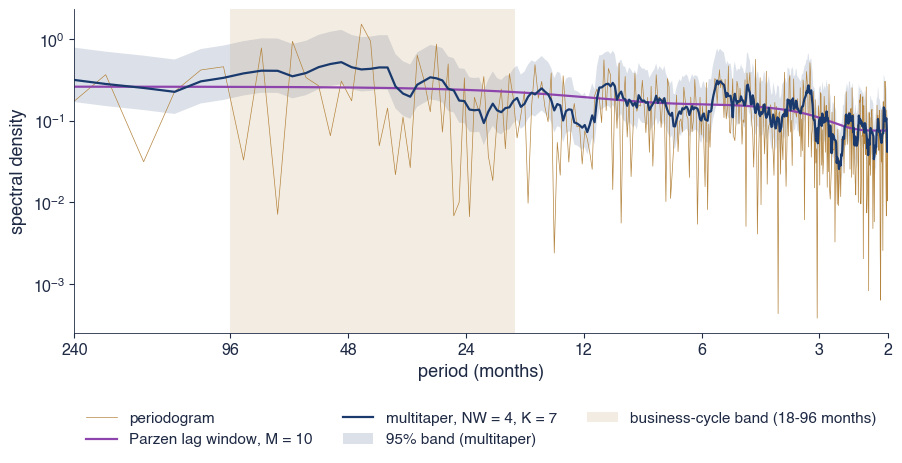

{'n': 799, 'start': '1960-02-01', 'end': '2026-08-01', 'M': 10.200217691696732, 'share_bc': 0.17519945265376666, 'share_bc_I': 0.18130687810285734, 'share_long': 0.04002243564601781, 'peak': 49.9375, 'ratio': 4.640294725112332}


In [16]:
# Solution
print(b1_us_ip(save_it=False))

**Interpretation of the result.** The Andrews rule is built for frequency zero and erases the 4-year peak; report the multitaper estimate.

## B2 [Proposed]: residual seasonality in German industry

**Question.** Does the seasonal adjustment leave seasonal or calendar lines? Model: B1.

1. Harmonic F test on the unadjusted and adjusted series.
2. p-values at k/12 and at 0.348 cycles per month.
3. Other significant frequencies against chance.
4. Interpretation.

**Report:** two sets of seven p-values, two counts, one sentence.

In [ ]:
# Your code here


## B3 [Solved]: output and unemployment by frequency

**Question.** At which frequencies do US industrial production and unemployment move together, and which leads?

1. Coherence and its 5% threshold.
2. Phase where coherence is significant; lead in months.
3. Business-cycle band against periods under 6 months.
4. Interpretation: is Okun's relation a business-cycle phenomenon?

**Report:** one chart, three numbers, one lead in months, one sentence.

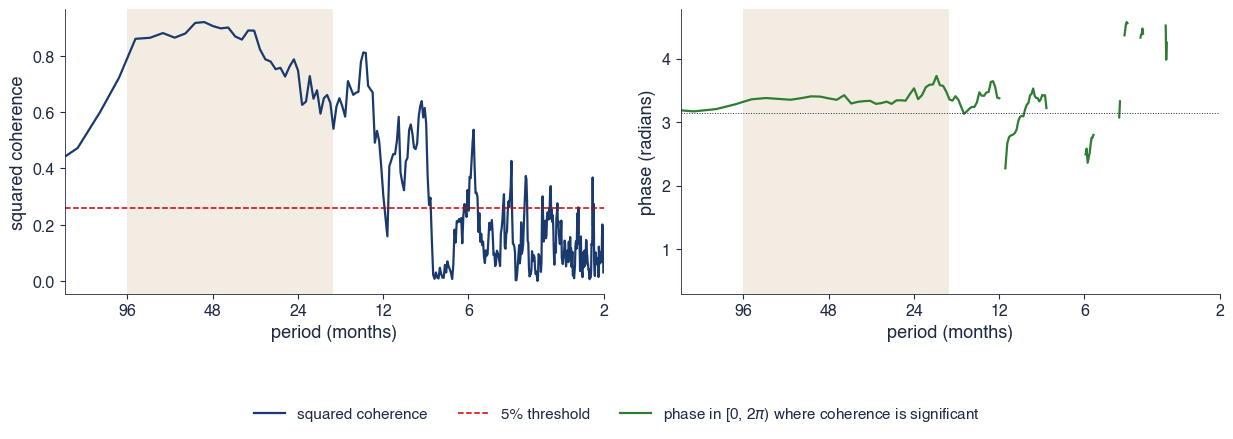

{'n': 719, 'start': '1960-02-01', 'end': '2019-12-01', 'K': 11, 'thr': 0.2588655508930522, 'coh_bc': 0.7861835134315733, 'coh_short': 0.1380949163922484, 'phase_bc': -2.873219595027738, 'lag_months': 1.3257882247672783, 'corr': -0.39619897745624666}


In [18]:
# Solution
print(b3_okun(save_it=False))

**Interpretation of the result.** Strong anti-phase coherence at business-cycle frequencies; production leads unemployment by about a month.

## B4 [Proposed]: the yield spread and growth by frequency

**Question.** Does the yield spread predict US output growth, and at which frequencies (Breitung and Candelon 2006)? Model: B3.

1. VAR order by AIC (at least 3); the Breitung-Candelon test over frequencies.
2. Range of rejections; p-values at 4, 8, 16, 32 quarters.
3. Repeat on 1960-2019.
4. Interpretation.

**Report:** one order, one range, four p-values, the same for the shorter sample, one sentence.

In [ ]:
# Your code here


## B5 [Solved]: four filters on US GDP

**Question.** Do HP, Baxter-King, Christiano-Fitzgerald and Hamilton tell the same story?

1. The four cycles and their standard deviations.
2. Correlations and troughs in 2008-2010 and 2020.
3. Hamilton coefficients and their sum.
4. Interpretation.

**Report:** four numbers, a correlation table, eight troughs, five coefficients, one sentence.

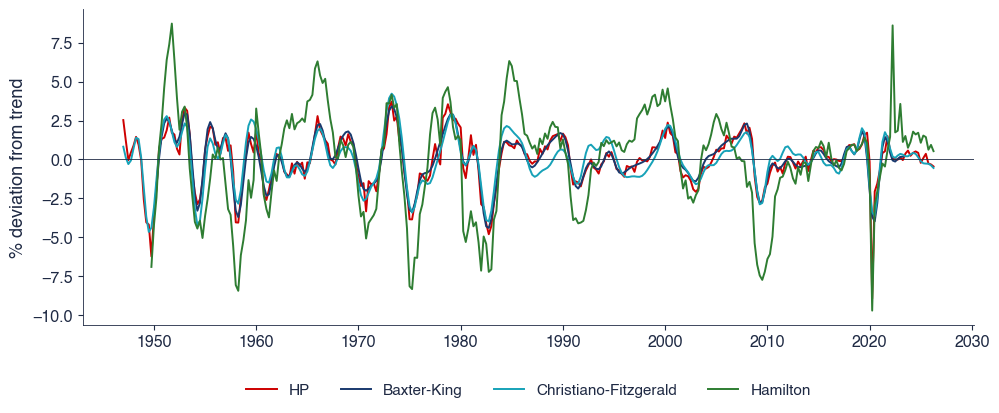

{'HP': 1.6188573754192483, 'Baxter-King': 1.4802043548579573, 'Christiano-Fitzgerald': 1.4990283548386574, 'Hamilton': 3.25200818917066}
{'HP|Hamilton': 0.7263598448894422, 'Baxter-King|HP': 0.9376839349517574, 'Baxter-King|Christiano-Fitzgerald': 0.913589823732642, 'Baxter-King|Hamilton': 0.7082800104627589, 'Christiano-Fitzgerald|HP': 0.8581449030598353, 'Christiano-Fitzgerald|Hamilton': 0.6407479751091337}
[25.1211874060332, 0.8940136008609141, -0.07807995235949675, -0.05184527878257149, 0.2152572838385988] 0.9793456535574446


In [20]:
# Solution
r = b5_us_filters(save_it=False)
print(r['sd'])
print(r['corr'])
print(r['b'], r['sumb'])

**Interpretation of the result.** The Hamilton coefficients sum to almost one: its cycle is close to 8-quarter growth.

## B6 [Proposed]: the euro-area output gap in real time

**Question.** How much would a real-time analyst have revised the euro-area cycle? Model: B5.

1. Final and real-time HP and Hamilton cycles.
2. Root mean square revision and sign revisions.
3. Compare with the standard deviations.
4. Interpretation.

**Report:** four numbers, two standard deviations, one sentence.

In [ ]:
# Your code here


## B7 [Solved]: Bitcoin and the S&P 500 in time and frequency

**Question.** Has Bitcoin become coupled with equities, and at which horizons?

1. Wavelet coherence and the Monte Carlo 5% contour (200 pairs here, 500 on the slides).
2. Significant share of the reliable area and its null 95th percentile.
3. Mean R² at 8-64 weeks in 2015-2019 and 2022-2026 against the correlations.
4. Interpretation.

**Report:** one chart, two shares, four numbers, one sentence.

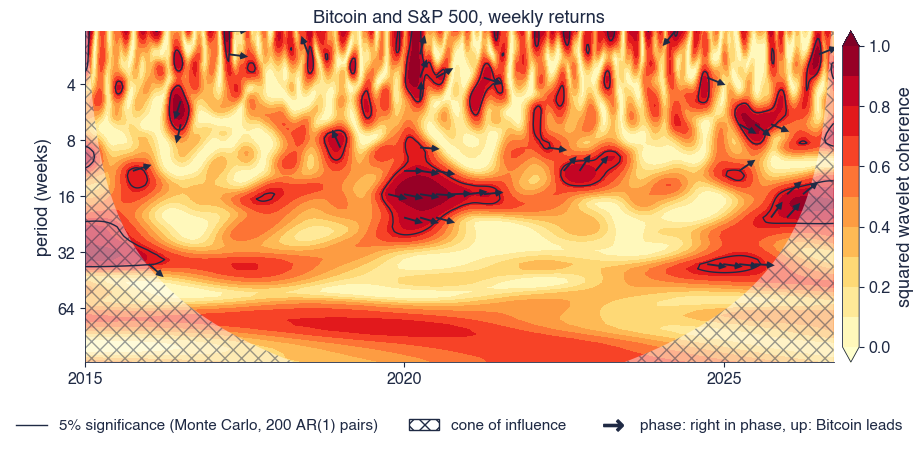

{'n': 611, 'start': '2015-01-09', 'end': '2026-09-18', 'share': 0.07361301189598905, 'null_q95': 0.0834929992630803, 'pre': 0.41308172385980035, 'post': 0.40428827841109294, 'covid': 0.3804849985150622, 'corr_pre': 0.05926865813745795, 'corr_post': 0.300404830034151, 'phase': 0.08192178032413847, 'reps': 200}


In [22]:
# Solution
print(b7_btc_spx(save_it=False, reps=200))

**Interpretation of the result.** Overall not distinguishable from independent series; coupling is episodic (2020).

## B8 [Proposed]: CEE stock markets and the DAX by scale

**Question.** How integrated are WIG20, BUX and PX with the DAX, horizon by horizon? Model: A7 and B7.

1. Wavelet correlation with the DAX at levels 1-8 with 95% intervals.
2. Wavelet beta at levels 1 and 8.
3. Compare with the daily correlation.
4. Interpretation.

**Report:** a chart, nine correlations, six betas, one sentence.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: are CEE business cycles converging to the euro area?

**Question.** Has synchronisation with the euro area increased for BG, CZ, HU, PL, RO, SK once common extreme shocks are accounted for? Model: B3.

1. A five-line pre-registration.
2. Band dynamic correlation (6-32 quarters) for 1996-2012, 2013-2026 and 2013-2019.
3. Interpretation: is the increase robust to excluding the pandemic?

**Report:** a five-line plan, a table, a project plan.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant answered:

- (a) the periodogram is a consistent estimator of the spectrum because it is asymptotically unbiased;
- (b) the HP filter with lambda = 1600 is a band-pass filter for cycles of 6 to 32 quarters;
- (c) a squared coherence of 0.30 estimated with 7 tapers is significant at 5%;
- (d) a phase of pi/2 at a period of 8 quarters means that the first series leads by 2 quarters;
- (e) the MODWT, like the DWT, needs a sample size that is a power of two;
- (f) wavelet coherence can be computed without smoothing; the smoothing only makes the picture nicer;
- (g) for the Morlet wavelet with w0 = 6 the Fourier period equals the scale;
- (h) a Breitung-Candelon test in a VAR(2) can find causality at some frequencies and not at others.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** eight verdicts with one line of justification each.

In [ ]:
# Your code here
